# 1.1｜用 MLP 预测房价 🏠

输入一套房的面积、房间数、房龄和距离，MLP 能输出一个价格吗？

本页沿着 **房源表 → 图像 → Tensor → 训练 → 比较 → 预测** 走一遍。第一次从上到下运行，第二次只改参数区的一行，看看结果怎么变。

- 建议先完成“认识数据与张量”和“训练规则与超参数”；首次训练约 20–30 分钟。
- 使用离线生成的 **600 套模拟房源**，金额单位统一为 **万元**。不是某座城市的真实成交记录，预测仅用于理解回归。

## 0. 准备

先运行这一格。绘图函数负责排版，计算函数负责训练；参数、数据形状、模型结构和训练步骤会在下文展示。

In [2]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "house_price.py").is_file():
    LAB_DIR = LAB_DIR / "01_mlp_lab"
if not (LAB_DIR / "house_price.py").is_file():
    raise FileNotFoundError("请在项目根目录或 01_mlp_lab 目录打开本页。")
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Markdown
from house_price import make_houses, prepare_data, build_model, train_model, predict_prices, price_metrics
from house_price_plots import (
    house_table, plot_data, plot_scaling, plot_losses, plot_training,
    plot_snapshots, plot_comparison, plot_predictions,
)

torch.set_num_threads(1)  # 每个 Notebook 只用一个 CPU 计算线程
print("准备完成，PyTorch 版本：", torch.__version__)

准备完成，PyTorch 版本： 2.11.0+cu128


## 1. 分类与回归：输出的含义变了

| 对比 | 前面的 moons 分类 | 本页房价回归 |
|---|---|---|
| 一个输入 | 两个坐标 | 四个房源特征 |
| 标签 | 类别 0 或 1 | 连续价格，例如 156.5 万元 |
| 输出层 | 两个类别分数 | 一个数 |
| 输出形状 | `[B, 2]` | `[B, 1]` |
| 常用损失 | CrossEntropyLoss | MSELoss / L1Loss / HuberLoss |
| 评价 | Accuracy | MAE / RMSE / R² |

回归末层直接输出数值，不加 Softmax，不做 argmax。本页输出的是**标准化价格**，随后会换算回万元。

## 2. 数据从哪里来？先划分，再看训练房源

| 列名 | 含义 | 模拟生成范围 |
|---|---|---|
| area_m2 | 面积 | 40–180 平方米 |
| rooms | 房间数 | 1–5 |
| age_years | 房龄 | 0–35 年 |
| distance_km | 距模拟城市中心的距离 | 0.5–20 公里 |
| price_wan | 要预测的总价，作为 y | 万元 |

生成器用四个特征、一些非线性关系和随机噪声构造价格。模型只看到房源和价格，**不会读取造价公式**。

先固定划分：训练集 60% 用于更新权重，验证集 20% 用于选择参数和训练轮次，测试集 20% 留到最后。探索图只看训练集，避免提前观察测试答案。

train: 360 套房源
val  : 120 套房源
test : 120 套房源


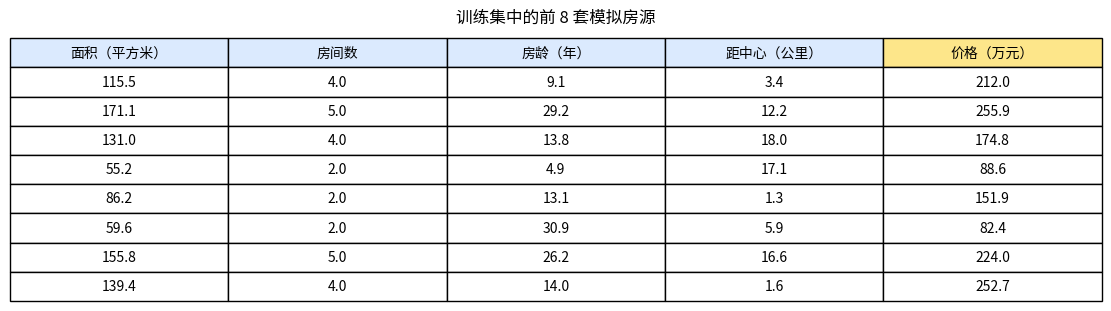

In [3]:
DATA_SEED = 42  # 比较模型时保持不变，保证房源和划分一致
X_raw, y_raw = make_houses(n_samples=600, seed=DATA_SEED)
data = prepare_data(X_raw, y_raw, seed=DATA_SEED)

for split in ("train", "val", "test"):
    print(f"{split:5s}: {len(data['indices'][split])} 套房源")
house_table(data["x_train_raw"], data["y_train_raw"])
plt.show()

**读表练习：** 哪些列是输入 X？哪一列是目标 y？一套房共有几个输入数字？

价格不应该混进输入特征，否则模型会提前看到答案。接着看下面的散点图。

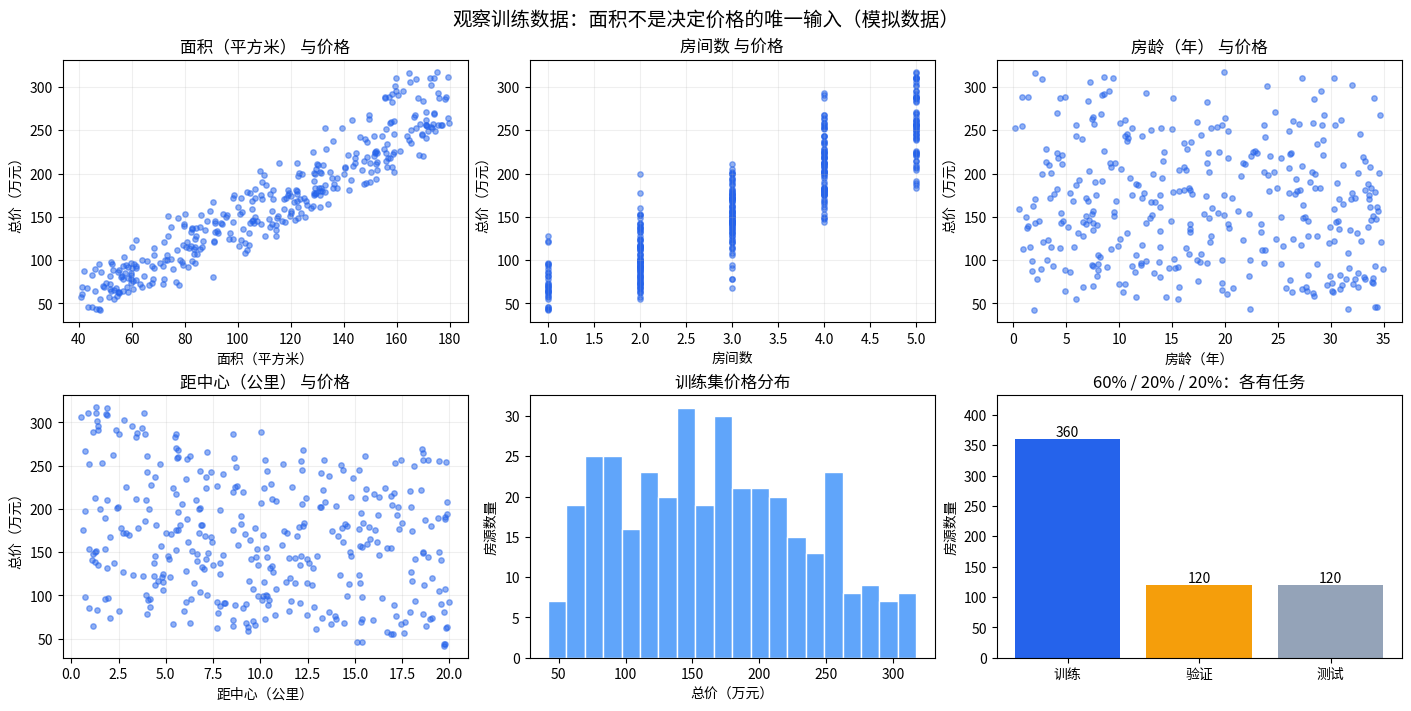

In [4]:
plot_data(data)
plt.show()

**读图提示：**

- 同样面积的房，为什么会出现不同价格？
- 房龄、距离、房间数能提供补充信息，但单张散点图不能证明因果关系。
- 价格分布告诉我们模型主要接触什么价格区间；远离训练范围属于外推。
- 图中关系由模拟规则决定，不能据此推断真实城市房价规律。

## 3. 表格怎样成为 Tensor？

一套房对应四元素向量；把 $B$ 套房按行叠起来：

$$
\mathbf{x}_i=[\mathrm{面积},\mathrm{房间数},\mathrm{房龄},\mathrm{距离}],\qquad
X_{\mathrm{batch}}\in\mathbb{R}^{B\times4},\quad y_{\mathrm{batch}}\in\mathbb{R}^{B\times1}
$$

平方米、年、公里尺度不同，因此先标准化。本页也标准化价格，减少目标尺度对优化的影响：

$$
x'_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\quad
y'_i=\frac{y_i-\mu_y}{\sigma_y},\quad
\widehat y_i=\widehat y'_i\sigma_y+\mu_y
$$

**均值和标准差只从训练集计算。** 验证集、测试集和新房源沿用相同参数，不能各自重新拟合标准化器。下面每个面板使用自己的色阶，以格子内的数值为准。

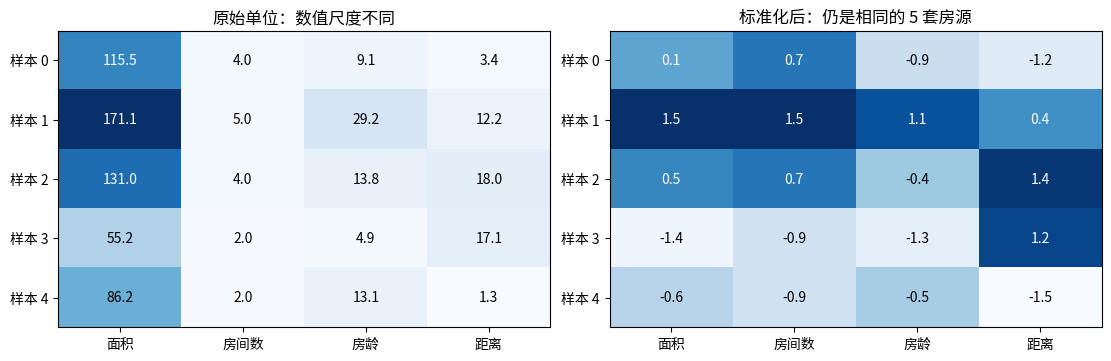

输入 X_train： (360, 4) torch.float32
目标 y_train： (360, 1) torch.float32
训练价格均值： 165.28 万元
训练价格标准差： 68.43 万元


In [5]:
plot_scaling(data)
plt.show()

print("输入 X_train：", tuple(data["x_train"].shape), data["x_train"].dtype)
print("目标 y_train：", tuple(data["y_train"].shape), data["y_train"].dtype)
print("训练价格均值：", round(float(data["y_scaler"].mean_[0]), 2), "万元")
print("训练价格标准差：", round(float(data["y_scaler"].scale_[0]), 2), "万元")
# y 保持 [N,1]，与模型输出一致，防止 [N] 和 [N,1] 被广播成 [N,N]。
assert data["y_train"].shape == (len(data["x_train"]), 1)

## 4. 参数修改区：先用默认值跑通

每次改完，重新运行从“查看模型”开始的后续单元；**只运行配置单元不会更新旧模型**。

| 参数 | 意义 | 可尝试值 |
|---|---|---|
| hidden_sizes | 各隐藏层宽度 | (16,)、(32,16)、(64,32) |
| activation | 隐藏层激活 | relu / tanh / sigmoid |
| loss | 训练损失 | mse / mae / huber |
| optimizer | 参数更新方法 | adam / sgd / rmsprop |
| lr | 学习率 | 0.001、0.003、0.01 |
| epochs | 完整遍历训练数据次数 | 40、120、200 |
| batch_size | 每批房源数量 | 16、32、64 |
| weight_decay | 权重衰减 | 0.0、0.0001 |
| seed | 初始化与批次顺序随机种子 | 比较时固定 42 |
| device | 计算设备 | 共享课堂默认 cpu |

weight_decay 是优化器提供的权重衰减参数，具体实现随优化器而异；本页先设为 0。SGD 使用默认的无动量版本。

In [ ]:
CONFIG = dict(
    hidden_sizes=(32, 16),   # 两个隐藏层：先 32 个特征，再 16 个
    activation="relu",      # relu / tanh / sigmoid
    loss="mse",             # mse / mae / huber
    optimizer="adam",       # adam / sgd / rmsprop
    lr=0.01,                # 学习率：一次更新的步长
    epochs=120,             # 完整遍历训练数据的次数
    batch_size=32,          # 最后一批可以不足 32
    weight_decay=0.0,       # 可从 0.0001 开始尝试
    seed=42,                # 单变量比较时保持相同
    device="cpu",
)
# 使用第 x 块 GPU：将 device 改为 "cuda:x"，x 替换成课堂分配编号。
# "cuda:3" 表示当前可见设备中编号 3 的 GPU；编号从 0 开始。
# 设置 CUDA_VISIBLE_DEVICES 时，这是映射后的可见编号，以课堂说明为准。

## 5. 看一眼模型：四个输入，一个输出

默认结构：`[B,4] → [B,32] → [B,16] → [B,1]`。隐藏层后的 ReLU 提供非线性。

末层输出的是标准化价格，负数表示低于训练价格均值，不代表原始房价为负。

In [ ]:
preview_model = build_model(CONFIG["hidden_sizes"], CONFIG["activation"])
print(preview_model)
print("可训练参数量：", sum(p.numel() for p in preview_model.parameters()))
with torch.no_grad():
    preview_output = preview_model(data["x_train"][:3])
print("3 套房源输入：", tuple(data["x_train"][:3].shape))
print("3 个价格输出：", tuple(preview_output.shape))
print("这是未训练的结构检查，不是最终预测。")
del preview_model, preview_output

Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
可训练参数量： 705
3 套房源输入： (3, 4)
3 个价格输出： (3, 1)
这是未训练的结构检查，不是最终预测。


## 6. 损失函数：怎样衡量“猜错了多少”？

误差 $e_i=\widehat y'_i-y'_i$ 位于**标准化价格尺度**。

$$
L_{\mathrm{MSE}}=\frac{1}{B}\sum_i e_i^2,\qquad
L_{\mathrm{MAE}}=\frac{1}{B}\sum_i |e_i|
$$

Huber 在小误差处使用二次项，大误差处使用线性项，本页固定 $\delta=1$：

$$
\ell_\delta(e)=\begin{cases}
\frac12e^2,& |e|\leq\delta\\
\delta(|e|-\frac12\delta),& |e|>\delta
\end{cases}
$$

这里 $\delta=1$ 对应**一个训练价格标准差**，不是 1 万元。

- MSE 对大误差惩罚更重；
- MAE 线性惩罚误差，在 PyTorch 中对应 L1Loss；
- Huber 在两种行为之间衔接，但并不保证每次效果最好。

不同损失尺度不同，不能用“谁的 Loss 数值小”判断谁预测更好。后续统一用万元尺度的验证 MAE 比较。

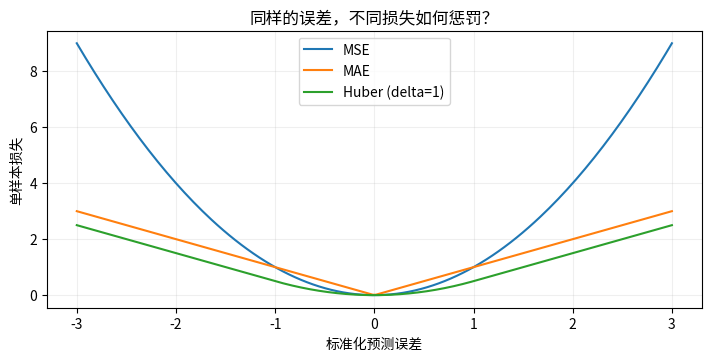

In [ ]:
plot_losses()
plt.show()

## 7. 开始训练：每批数据做什么？

辅助模块中的关键更新步骤：

```python
optimizer.zero_grad()             # 1. 清除上一批梯度
prediction = model(xb)            # 2. 前向：[B,4] → [B,1]
loss = criterion(prediction, yb)  # 3. 衡量预测误差
loss.backward()                  # 4. 计算参数梯度
optimizer.step()                 # 5. 更新参数
```

这段说明代码不必单独运行，下面的函数会执行同一训练循环：

- 每轮完成后，在 eval() 和 no_grad() 状态评价训练集、验证集；
- 验证数据不参与反向传播，记录每轮 Loss 和 MAE；
- 完整运行指定轮数，返回**验证 MAE 最小轮次**的模型；
- 记录 Epoch 0、1、10、40 和最后一轮的验证预测。

选取最佳轮次不等于提前停止，本页仍然运行全部 epochs。

训练完成！
所选 Epoch： 29
验证 MAE：7.17 万元


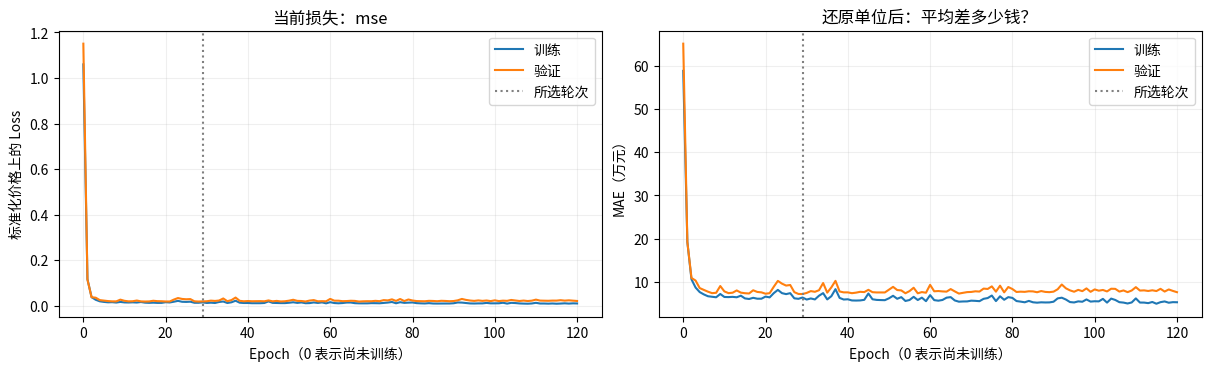

In [ ]:
baseline = train_model(data, **CONFIG)
print("训练完成！")
print("所选 Epoch：", baseline["best_epoch"])
print(f"验证 MAE：{baseline['val_mae']:.2f} 万元")
plot_training(baseline)
plt.show()

左图是当前损失函数的训练/验证曲线，右图把误差换算为万元。

**先读图：** 训练误差继续下降、验证误差上升，可能开始过拟合；两者都很高，可能训练不足、模型过于简单或学习率不合适。验证曲线不要求每轮单调下降。灰色竖线是返回模型的轮次。

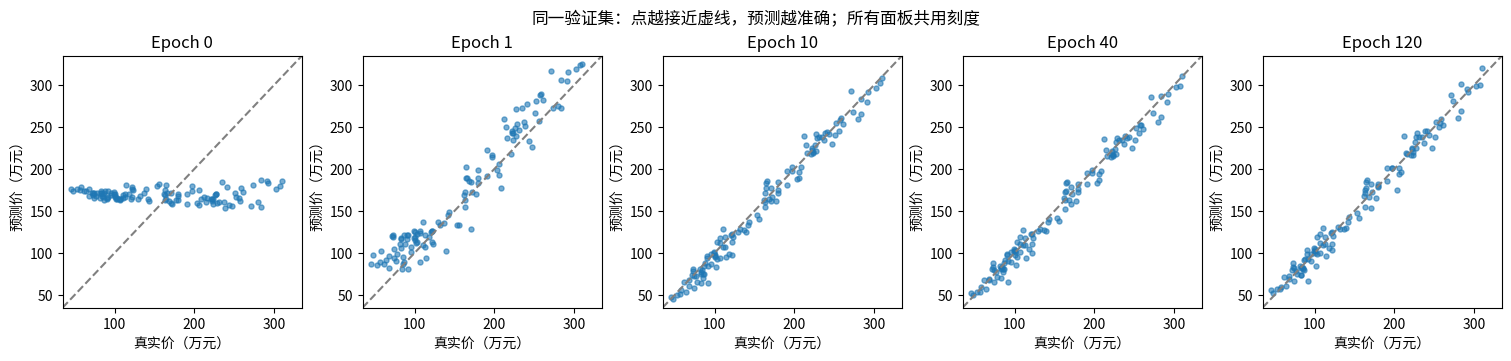

In [ ]:
plot_snapshots(baseline, data)
plt.show()

每个点对应验证集的一套房。横轴是真实价、纵轴是预测价，虚线表示预测正确，各面板共用刻度。

**观察：** 点是否逐渐靠近虚线？最后一轮一定优于中间轮次吗？阶段图展示当轮模型，最终返回的是验证 MAE 最小轮次的模型。

## 8. 自由实验：一次只改一项

下面每组都从 CONFIG 和新初始化的模型开始，使用同样的数据划分、种子和训练预算，不会接着训练上一组。

可以修改、增加或删除 EXPERIMENTS 中的行，例如 `{"optimizer": "rmsprop"}`、`{"lr": 0.003}` 或 `{"batch_size": 64}`。

比较回答“当前条件下改一项会怎样”。相同学习率不代表各优化器已经分别调到最佳；一次结果不能说明哪个优化器普遍更优。

改用 MAE：验证 MAE=7.25 万元


改用 Huber：验证 MAE=7.18 万元


改用 SGD：验证 MAE=8.53 万元


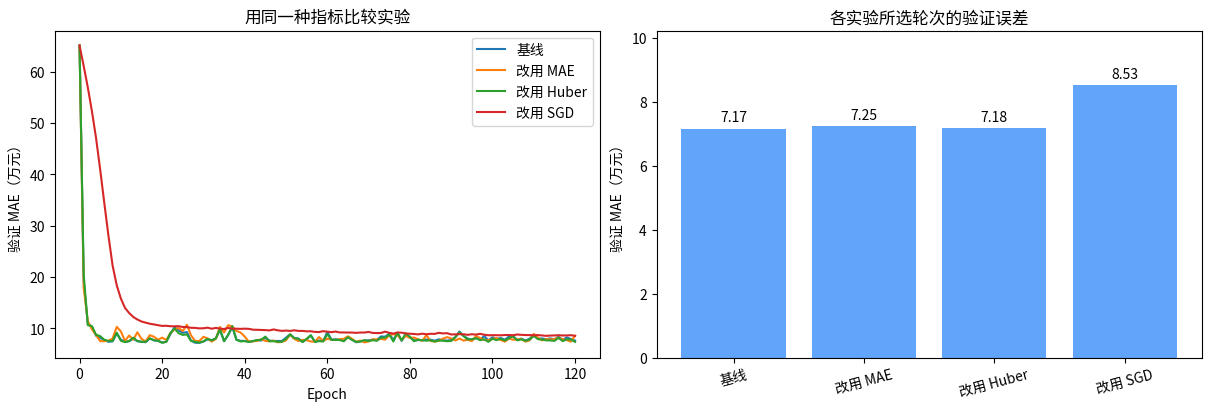

In [ ]:
EXPERIMENTS = {
    "改用 MAE": {"loss": "mae"},
    "改用 Huber": {"loss": "huber"},
    "改用 SGD": {"optimizer": "sgd"},
    # "改用 RMSprop": {"optimizer": "rmsprop"},
    # "更宽的隐藏层": {"hidden_sizes": (64, 32)},
}
results = {"基线": baseline}
for name, change in EXPERIMENTS.items():
    results[name] = train_model(data, **{**CONFIG, **change})
    print(f"{name}：验证 MAE={results[name]['val_mae']:.2f} 万元")

plot_comparison(results)
plt.show()

### 8.1 我的第一次调参

先写预测，再改 MY_CHANGE 中的一项。每次运行会重新训练并覆盖“我的实验”的结果。先计划少量比较，完成后再打开测试集；反复筛选会使结果偏向验证集。

**我的预测：** 我改了 ______；预计验证 MAE 会 ______；理由是 ______。

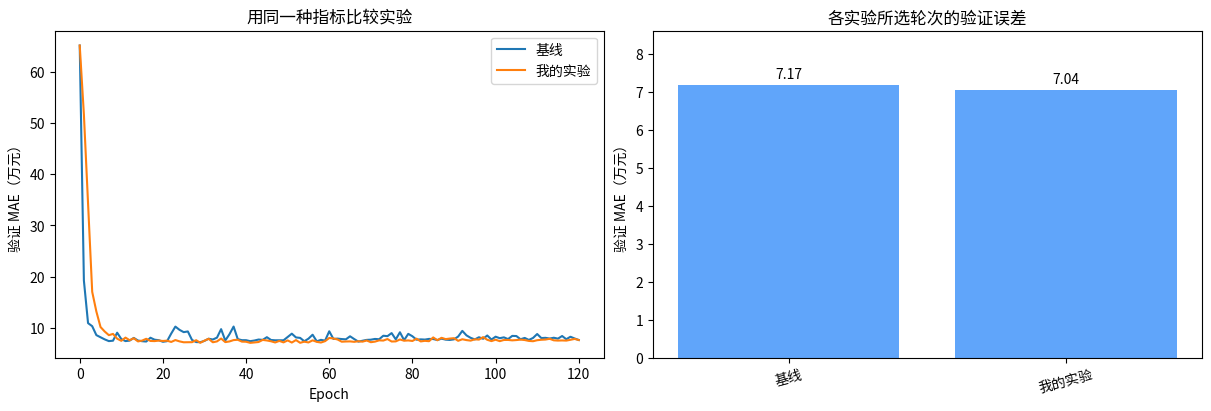

| 实验 | loss | optimizer | lr | epochs | 所选轮次 | 验证 MAE（万元） |
|---|---|---|---:|---:|---:|---:|
| 基线 | mse | adam | 0.01 | 120 | 29 | 7.17 |
| 改用 MAE | mae | adam | 0.01 | 120 | 69 | 7.25 |
| 改用 Huber | huber | adam | 0.01 | 120 | 20 | 7.18 |
| 改用 SGD | mse | sgd | 0.01 | 120 | 120 | 8.53 |
| 我的实验 | mse | adam | 0.003 | 120 | 41 | 7.04 |

In [ ]:
MY_CHANGE = {"lr": 0.003}  # 只改这里，例如 {"epochs": 60}
results["我的实验"] = train_model(data, **{**CONFIG, **MY_CHANGE})
plot_comparison({"基线": baseline, "我的实验": results["我的实验"]})
plt.show()

rows = ["| 实验 | loss | optimizer | lr | epochs | 所选轮次 | 验证 MAE（万元） |",
        "|---|---|---|---:|---:|---:|---:|"]
for name, result in results.items():
    c = result["config"]
    rows.append(f"| {name} | {c['loss']} | {c['optimizer']} | {c['lr']} | {c['epochs']} | {result['best_epoch']} | {result['val_mae']:.2f} |")
display(Markdown("\n".join(rows)))

## 9. 最后检验：测试集与简单基线

按验证 MAE 选择一个候选模型，再查看测试预测。此后不根据测试结果继续挑选模型。

加入一个简单基线：**对每套房都猜训练集平均价格**，看看 MLP 是否学到了有用信息。

$$
\mathrm{MAE}=\frac1N\sum_i|\widehat y_i-y_i|,\quad
\mathrm{RMSE}=\sqrt{\frac1N\sum_i(\widehat y_i-y_i)^2}
$$

$$
R^2=1-\frac{\sum_i(\widehat y_i-y_i)^2}{\sum_i(y_i-\overline y)^2}
$$

- MAE：平均差多少万元；
- RMSE：单位也是万元，对大误差更敏感；
- R²：拟合优度，1 表示完全拟合，可能为负，**不是准确率**。
- R² 的分母使用当前评价集均值；常数基线使用训练均值，因而其 R² 不一定等于 0。

测试只反映当前模拟分布，不代表真实市场效果。

按验证集选中的实验： 我的实验
训练均值基线：MAE=54.32 万元，RMSE=62.61 万元，R²=-0.012
所选 MLP：MAE=7.04 万元，RMSE=8.90 万元，R²=0.980


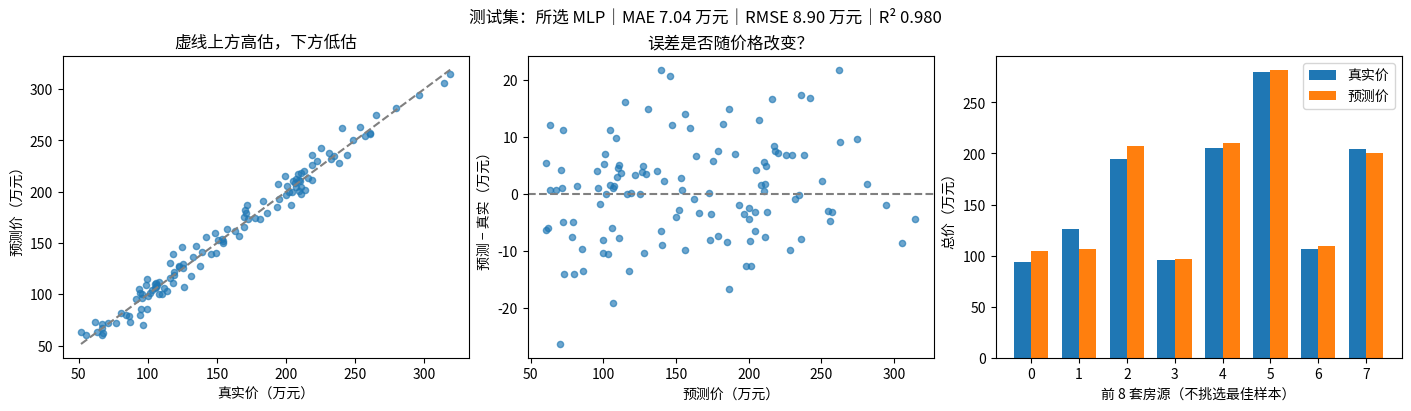

In [ ]:
selected_name = min(results, key=lambda name: results[name]["val_mae"])
selected = results[selected_name]
test_prediction = predict_prices(selected, data, data["x_test_raw"])
mean_prediction = np.full_like(data["y_test_raw"], data["y_scaler"].mean_[0])

print("按验证集选中的实验：", selected_name)
for name, prediction in [("训练均值基线", mean_prediction), ("所选 MLP", test_prediction)]:
    m = price_metrics(data["y_test_raw"], prediction)
    print(f"{name}：MAE={m['MAE']:.2f} 万元，RMSE={m['RMSE']:.2f} 万元，R²={m['R2']:.3f}")

plot_predictions(data["y_test_raw"], test_prediction, title="测试集：所选 MLP")
plt.show()

## 10. 输入自己的房源

修改 HOUSE 中四个数字。顺序和单位必须一致：**面积（平方米）、房间数、房龄（年）、距中心（公里）**。

预测沿用训练时的标准化器，并自动换算为万元。这是点预测，没有价格区间保证。输入超出训练范围时会提醒外推。

这套模拟房源的预测总价：163.5 万元


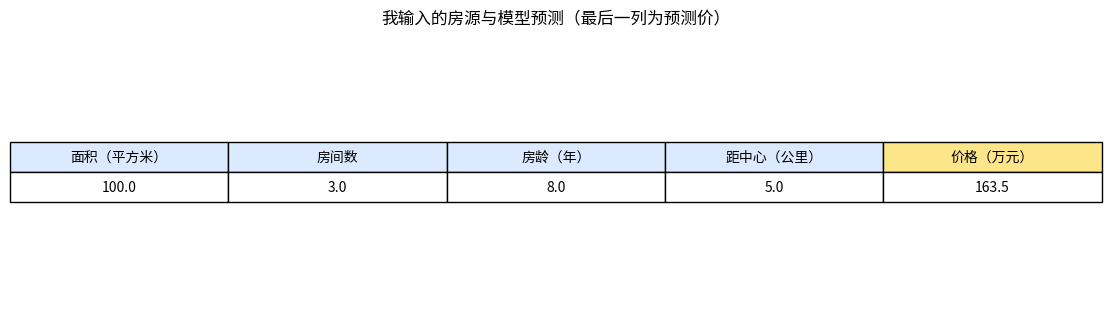

In [ ]:
HOUSE = [100.0, 3, 8.0, 5.0]  # 改这里，再运行本单元
new_houses = np.array([HOUSE], dtype=np.float32)
new_price = predict_prices(selected, data, new_houses, check_range=True)
print(f"这套模拟房源的预测总价：{new_price[0, 0]:.1f} 万元")
house_table(new_houses, new_price, title="我输入的房源与模型预测（最后一列为预测价）")
plt.show()

### 10.1 只改变面积，会怎样？

保持房间数、房龄、距离不变，让面积从 50 到 170 平方米变化，观察响应是否平滑。

这只是模型行为检查。人工组合的特征不一定代表常见房源，曲线不代表“增大面积导致真实房价变化”的因果结论。

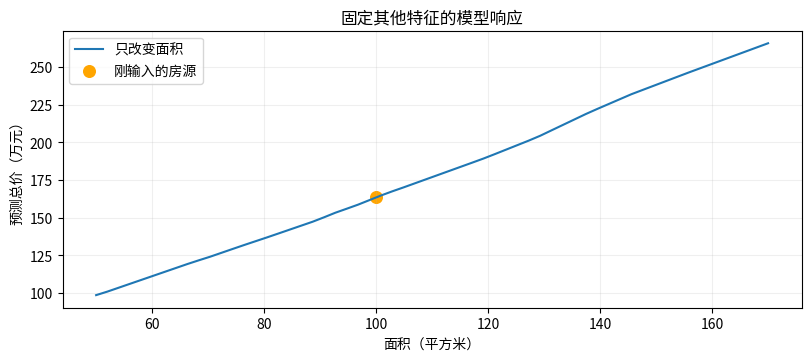

In [ ]:
area_grid = np.linspace(50, 170, 60, dtype=np.float32)
probe_houses = np.repeat(new_houses, len(area_grid), axis=0)
probe_houses[:, 0] = area_grid
probe_price = predict_prices(selected, data, probe_houses)

fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
ax.plot(area_grid, probe_price[:, 0], label="只改变面积")
ax.scatter([HOUSE[0]], [new_price[0, 0]], color="orange", s=70, label="刚输入的房源")
ax.set(xlabel="面积（平方米）", ylabel="预测总价（万元）", title="固定其他特征的模型响应")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 11. 换成自己的 CSV：从数据入口换起

课后可使用同一格式的数值 CSV，价格必须统一为万元：

```csv
area_m2,rooms,age_years,distance_km,price_wan
100,3,8,5,168
80,2,15,9,112
```

上面只有两行格式示意，实际至少需要 30 条；小数据的评价会不稳定。先处理缺失值、文本类别、重复房源和异常单位。

将第 2 节数据生成与准备部分替换为以下代码，再运行后续单元：

```python
table = np.genfromtxt(LAB_DIR / "houses.csv", delimiter=",", names=True, encoding="utf-8-sig")
table = np.atleast_1d(table)
X_raw = np.column_stack([table[name] for name in
                        ("area_m2", "rooms", "age_years", "distance_km")])
y_raw = table["price_wan"].reshape(-1, 1)
data = prepare_data(X_raw, y_raw, seed=DATA_SEED)
```

图表使用四个固定特征。改变特征数或语义时，需要同步修改模型输入层、特征名和房源预测代码。真实数据可能按小区或时间聚集，同一房源也可能重复出现，不能直接照搬随机划分声称真实泛化能力。

## 12. 练习与结果记录

| 练习 | 修改内容 | 观察 |
|---|---|---|
| 学习率 | 0.01 → 0.003 | 收敛速度、验证 MAE |
| Batch | 32 → 64 | 每轮更新次数、验证曲线 |
| 隐藏层 | (32,16) → (16,) | 参数量、训练和验证误差 |
| 损失 | MSE → MAE / Huber | 统一万元 MAE，不直接比不同 Loss |
| 优化器 | Adam → SGD / RMSprop | 当前固定条件下的收敛 |
| 轮数 | 120 → 40 | 是否训练不足、所选轮次变化 |

> 我只修改了 ______。在固定数据和种子下，验证 MAE 从 ______ 万元变为 ______ 万元。曲线显示 ______。这次结果支持 ______，还不能说明 ______。

常见问题：

- NameError：检查是否漏运行准备、配置、训练单元。
- Loss 跳动很大或非有限：先降低学习率，检查数据与标准化。
- 形状不匹配：输入应为 `[N,4]`，目标为 `[N,1]`。
- 改参数图没变：重新运行训练和后续单元，旧模型不会自动更新。
- GPU 不可用：保持 `device="cpu"`，本页数据很小。

阅读代码时，先看 `house_price.py` 中的 `build_model()`，再看 `train_model()` 的五步更新。绘图排版位于 `house_price_plots.py`。

参考：[PyTorch MSELoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)、[PyTorch HuberLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.HuberLoss.html)、[scikit-learn：避免数据泄漏](https://scikit-learn.org/stable/common_pitfalls.html)。

## 结束本页：保存结果，关闭当前内核

先保存 Notebook，再运行最后一格。它会清空变量、关闭图形并结束当前内核；共享此内核的其他 Notebook 也会断开。

**Run All 会执行这一格。** 提示内核已停止属于预期行为。继续调参时，重新选择内核并从头运行；也可以第一次运行到这一格前暂时停下。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("已清理当前 Notebook 资源，正在结束内核……")
get_ipython().kernel.do_shutdown(restart=False)

已清理当前 Notebook 资源，正在结束内核……


{'status': 'ok', 'restart': False}

: 